<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


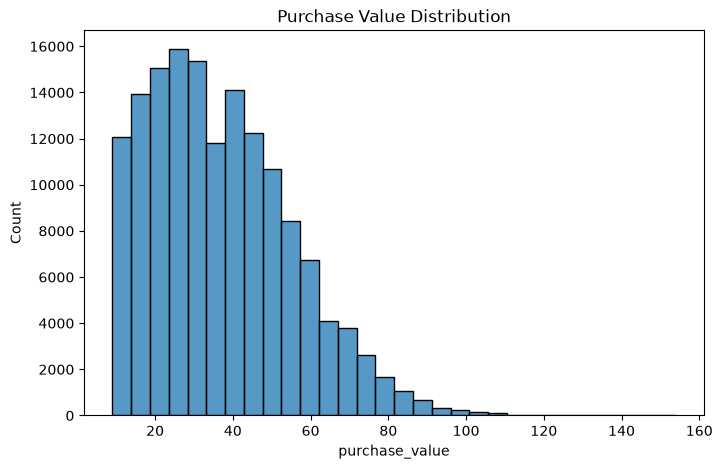

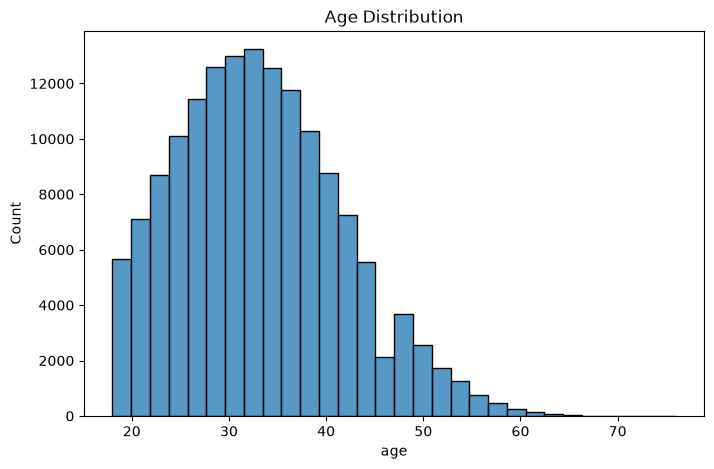

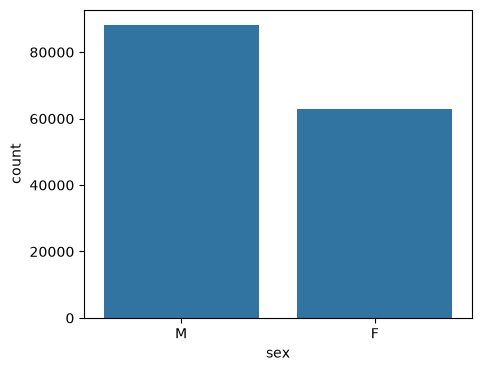

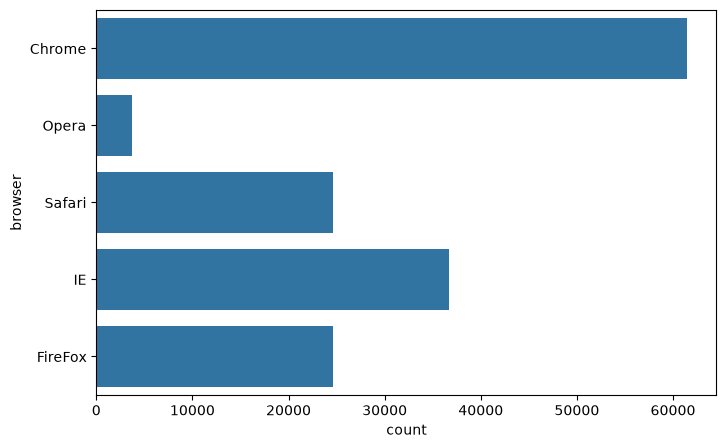

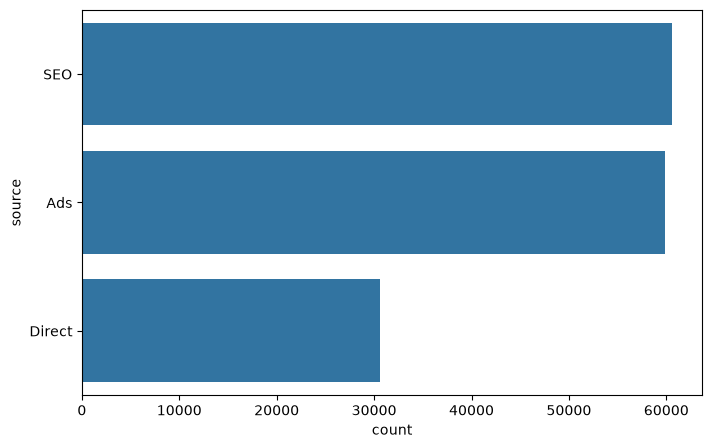

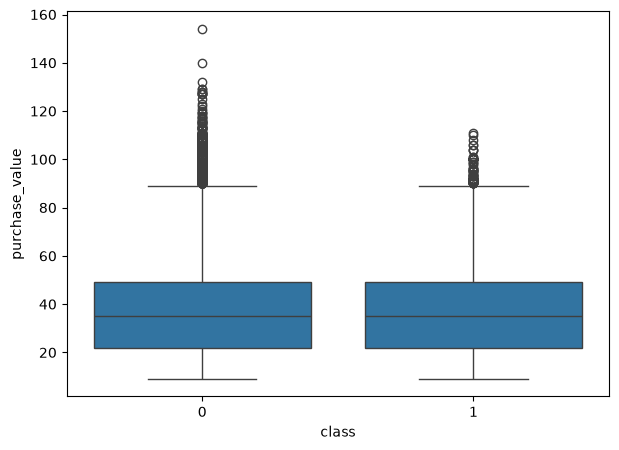

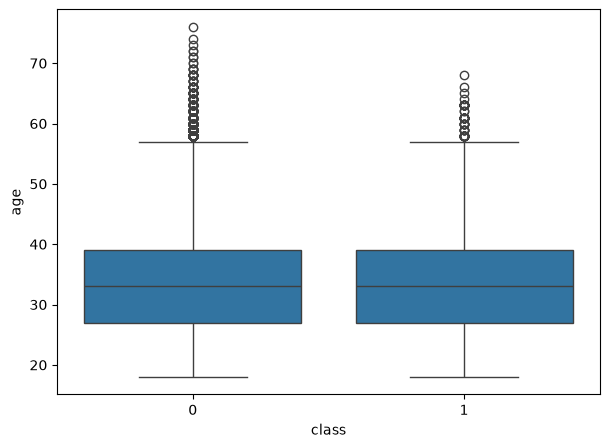

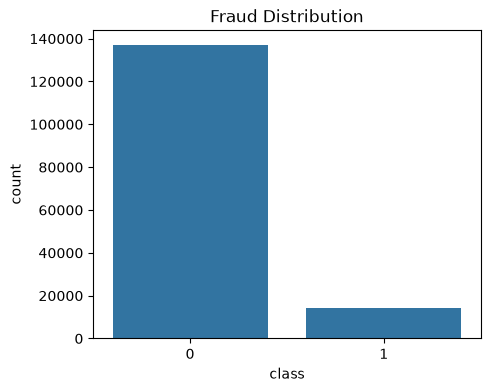

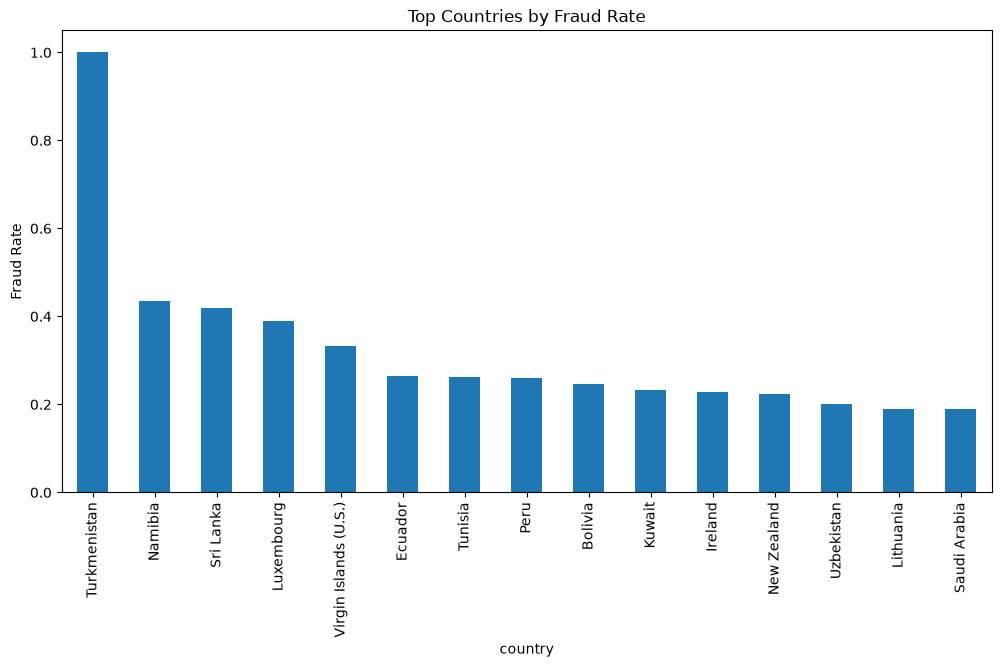

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

fraud_df = pd.read_csv('../data/Fraud_Data.csv')

fraud_df.head()
fraud_df.shape
fraud_df.info()
fraud_df.isnull().sum()
fraud_df.duplicated().sum()
fraud_df.drop_duplicates(inplace=True)

fraud_df["signup_time"] = pd.to_datetime(fraud_df["signup_time"])
fraud_df["purchase_time"] = pd.to_datetime(fraud_df["purchase_time"])

plt.figure(figsize=(8,5))
sns.histplot(fraud_df["purchase_value"], bins=30)
plt.title("Purchase Value Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(fraud_df["age"], bins=30)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(data=fraud_df, x="sex")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=fraud_df, y="browser")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=fraud_df, y="source")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(data=fraud_df, x="class", y="purchase_value")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(data=fraud_df, x="class", y="age")
plt.show()

pd.crosstab(fraud_df["browser"], fraud_df["class"])

fraud_df["class"].value_counts()
fraud_df["class"].value_counts(normalize=True) * 100

plt.figure(figsize=(5,4))
sns.countplot(data=fraud_df, x="class")
plt.title("Fraud Distribution")
plt.show()

fraud_df["time_since_signup"] = (
    fraud_df["purchase_time"] - fraud_df["signup_time"]
).dt.total_seconds() / 3600

fraud_df["hour_of_day"] = fraud_df["purchase_time"].dt.hour
fraud_df["day_of_week"] = fraud_df["purchase_time"].dt.day_name()

fraud_df["transaction_count"] = fraud_df.groupby("user_id")["user_id"].transform("count")

fraud_df["ip_address"] = fraud_df["ip_address"].astype(np.int64)

ip_df = pd.read_csv("../data/IpAddress_to_Country.csv")
ip_df["lower_bound_ip_address"] = ip_df["lower_bound_ip_address"].astype(np.int64)
ip_df["upper_bound_ip_address"] = ip_df["upper_bound_ip_address"].astype(np.int64)

fraud_df = fraud_df.sort_values("ip_address")
ip_df = ip_df.sort_values("lower_bound_ip_address")

fraud_df = pd.merge_asof(
    fraud_df,
    ip_df,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

fraud_df = fraud_df[fraud_df["ip_address"] <= fraud_df["upper_bound_ip_address"]]

country_fraud = fraud_df.groupby("country")["class"].mean().sort_values(ascending=False)
country_fraud.head(20)

plt.figure(figsize=(12,6))
country_fraud.head(15).plot(kind="bar")
plt.title("Top Countries by Fraud Rate")
plt.ylabel("Fraud Rate")
plt.show()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ["purchase_value", "age", "time_since_signup", "transaction_count"]
fraud_df[num_cols] = scaler.fit_transform(fraud_df[num_cols])

fraud_df = pd.get_dummies(
    fraud_df,
    columns=["sex", "browser", "source", "day_of_week", "country"],
    drop_first=True
)

fraud_df.to_csv("../data/processed_fraud.csv", index=False)